# Bagging
Bagging is a technique which is done in 2 steps one is Bootstraping and other is Aggregatn. In this first bootstraping is done where random subset of data is formed and passed/feed to all models(same) and then in next step when a new query pt comes, it passes to all models and then aggregatn is done where Decision is made on Majority count

- Bias : Accuracy on training data
- Variance : Variatn in data given to model

> Why to use Bagging
- Use Bagging if we have LBHV.
- As to give best result, model should be LBLV(low bias low variance)
- In bagging we take models with LBHV like DT,SVM,kNN -> Overfitting as have high variance
- So we give them random data with new additional data added to them 
- Due to this, we achieve the model which is a LBLV model that produce consistent results

In [2]:
import numpy as np
import pandas as pd 
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\iris_data.csv')

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
en = LabelEncoder()
df['Species'] = en.fit_transform(df['Species'])

In [8]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [9]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

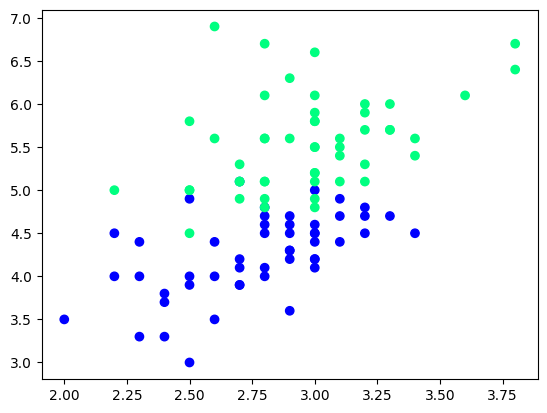

In [11]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'],c=df['Species'],cmap='winter')

> Difference btw sampling and pasting
- In bagging, we do row sampling with replacement or same sample pts
- But in pasting, we do row sampling without replacement
- random subspaces : colwise sampling
- Random patches: do both roe abd col sampling

In [25]:
# Taking only 10 rows for training
df = df.sample(100)
df_tr = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_ts = df.iloc[80:,:].sample(5)

In [26]:
x_ts = df_val.iloc[:,0:2].values
y_ts = df_val.iloc[:,-1].values

> Case 1: Bagging or Bootstraping

In [27]:
# Data for tree 1
df_bag = df_tr.sample(8,replace=True) # here we allow replacement/duplicatn
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
142,2.7,5.1,2
86,3.1,4.7,1
95,3.0,4.2,1
95,3.0,4.2,1
148,3.4,5.4,2
95,3.0,4.2,1
96,2.9,4.2,1


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [29]:
# because max_depth=None therefore it is LBHV model
dt_bag1 = DecisionTreeClassifier()

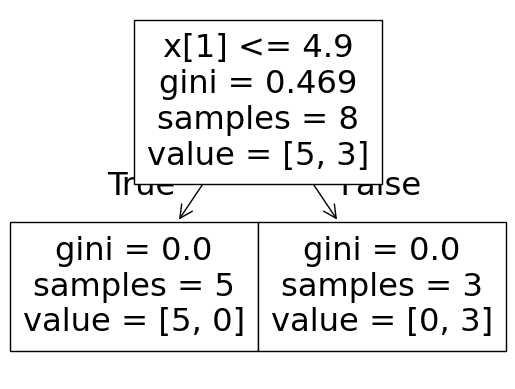

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


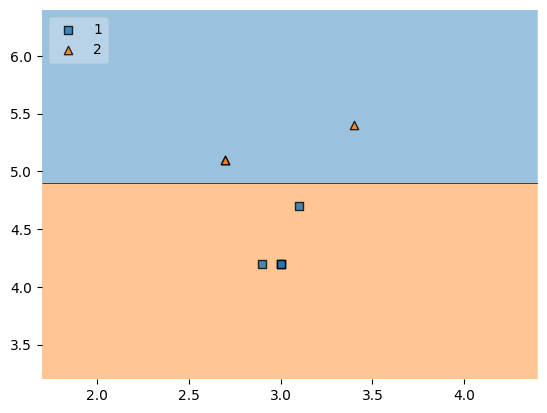

In [30]:
evaluate(dt_bag1,x,y)

In [31]:
# Data for tree 1
df_bag = df_tr.sample(8,replace=True)

# fetch x,y
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
148,3.4,5.4,2
114,2.8,5.1,2
116,3.0,5.5,2
142,2.7,5.1,2
135,3.0,6.1,2
142,2.7,5.1,2
148,3.4,5.4,2
70,3.2,4.8,1


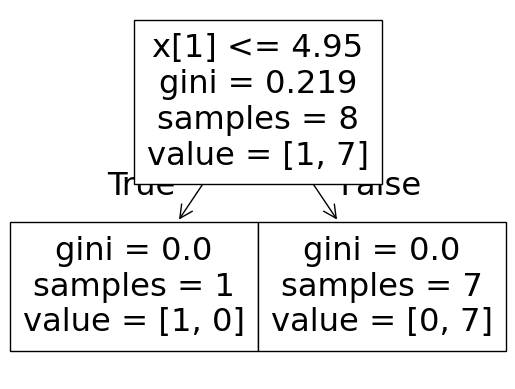

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


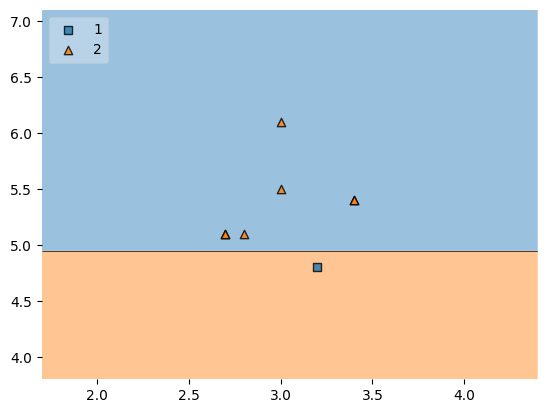

In [32]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

In [33]:
# Data for tree 3
df_bag = df_tr.sample(8,replace=True) 
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
95,3.0,4.2,1
96,2.9,4.2,1
70,3.2,4.8,1
148,3.4,5.4,2
142,2.7,5.1,2
114,2.8,5.1,2
95,3.0,4.2,1


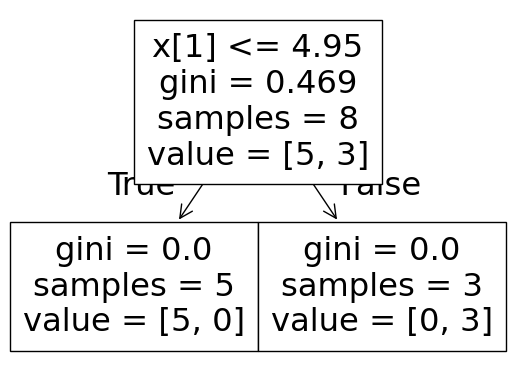

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


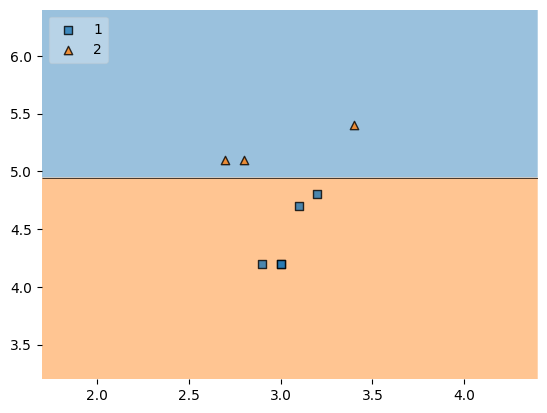

In [34]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

In [35]:
def evaluate(clf,x,y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(x_ts)
    print(accuracy_score(y_ts,y_pred))

> Part2: Predcit

In [36]:
df_ts

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
147,3.0,5.2,2
108,2.5,5.8,2
52,3.1,4.9,1
119,2.2,5.0,2


In [37]:
print("Predictor 1",dt_bag1.predict(np.array([3.2,4.7]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.2,4.7]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.2,4.7]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


> Types of Bagging
1. Pasting
2. 

# Pasting
Row sampling without replacement

In [38]:
df_tr

,SepalWidthCm,PetalLengthCm,Species
114,2.8,5.1,2
96,2.9,4.2,1
148,3.4,5.4,2
86,3.1,4.7,1
135,3.0,6.1,2
142,2.7,5.1,2
70,3.2,4.8,1
116,3.0,5.5,2
95,3.0,4.2,1
104,3.0,5.8,2


In [39]:
df_tr.sample(8)

,SepalWidthCm,PetalLengthCm,Species
114,2.8,5.1,2
86,3.1,4.7,1
95,3.0,4.2,1
135,3.0,6.1,2
104,3.0,5.8,2
148,3.4,5.4,2
70,3.2,4.8,1
142,2.7,5.1,2


# Random SubSpaces
Doing Column Sampling with or without replacement

In [40]:
df1 = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\iris_data.csv')
df1.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
98,99,5.1,2.5,3.0,1.1,Iris-versicolor
141,142,6.9,3.1,5.1,2.3,Iris-virginica
48,49,5.3,3.7,1.5,0.2,Iris-setosa
149,150,5.9,3.0,5.1,1.8,Iris-virginica
61,62,5.9,3.0,4.2,1.5,Iris-versicolor
123,124,6.3,2.7,4.9,1.8,Iris-virginica
14,15,5.8,4.0,1.2,0.2,Iris-setosa
143,144,6.8,3.2,5.9,2.3,Iris-virginica
129,130,7.2,3.0,5.8,1.6,Iris-virginica
63,64,6.1,2.9,4.7,1.4,Iris-versicolor


In [41]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,Species
0,5.1,Iris-setosa
1,4.9,Iris-setosa
2,4.7,Iris-setosa
3,4.6,Iris-setosa
4,5.0,Iris-setosa
...,...,...
145,6.7,Iris-virginica
146,6.3,Iris-virginica
147,6.5,Iris-virginica
148,6.2,Iris-virginica


# Random Patches
In this, we do both row and col sampling

Used when have more no of cols

In [42]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [43]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,Id,PetalWidthCm
36,37,0.2
73,74,1.2
41,42,0.3
81,82,1.0
127,128,1.8
147,148,2.0
45,46,0.3
54,55,1.5
